# 使用PyTorch 模块搭建神经网络


In [25]:
%matplotlib inline


In [26]:
import torch
import numpy as np
import torch.optim as optim

In [27]:
torch.set_printoptions(edgeitems=2,linewidth=75)

In [28]:
t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c).unsqueeze(1)
t_u = torch.tensor(t_u).unsqueeze(1)

In [29]:
t_u.shape

torch.Size([11, 1])

In [30]:
# n_samples = t_u.shape[0]
# n_val = int(0.2 * n_samples)

# shuffled_indices = torch.randperm(n_samples)
# train_indices = shuffled_indices[:-n_val]
# val_indices = shuffled_indices[-n_val:]
# t_u_train = t_u[train_indices]
# t_c_train = t_c[train_indices]

# t_u_val = t_u[val_indices]
# t_c_val = t_c[val_indices]

# t_un_train = 0.1 * t_u_train
# t_un_val = 0.1 * t_u_val

n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

t_u_train = t_u[train_indices]
t_c_train = t_c[train_indices]

t_u_val = t_u[val_indices]
t_c_val = t_c[val_indices]

t_un_train = 0.1 * t_u_train
t_un_val = 0.1 * t_u_val

In [31]:
import torch.nn as nn
linear_model = nn.Linear(1,1)
linear_model(t_un_val)

tensor([[3.5261],
        [2.3210]], grad_fn=<AddmmBackward0>)

In [32]:
linear_model.weight


Parameter containing:
tensor([[0.4635]], requires_grad=True)

In [33]:
linear_model.bias

Parameter containing:
tensor([-0.2699], requires_grad=True)

In [34]:
x = torch.ones(10,1)
linear_model(x)

tensor([[0.1936],
        [0.1936],
        [0.1936],
        [0.1936],
        [0.1936],
        [0.1936],
        [0.1936],
        [0.1936],
        [0.1936],
        [0.1936]], grad_fn=<AddmmBackward0>)

In [35]:
optimizer = optim.SGD(linear_model.parameters(), lr=1e-2)

In [36]:
list(linear_model.parameters())

[Parameter containing:
 tensor([[0.4635]], requires_grad=True),
 Parameter containing:
 tensor([-0.2699], requires_grad=True)]

In [45]:
def train_loop(n_epochs, optimizer, model, loss_fn, t_u_train, t_u_val, t_c_train, t_c_val):
    for epoch in range(1,n_epochs+1):
        t_p_train = model(t_u_train)
        loss_train = loss_fn(t_p_train, t_c_train)
        t_p_val = model(t_u_val)
        loss_val = loss_fn(t_p_val, t_c_val)
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        if epoch == 1 or epoch % 1000 == 0:
            print(f'Epoch {epoch}, Training Loss: {loss_train.item():0.4f}, Validation Loss: {loss_val.item():0.4f}')

In [46]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

In [63]:
linear_model = nn.Linear(1,1)
optimizer = optim.SGD(linear_model.parameters(),
    lr=1e-2)

train_loop(
    n_epochs = 3000,
    optimizer = optimizer,
    model = linear_model,
    loss_fn = loss_fn,
    t_u_train = t_un_train,
    t_u_val = t_un_val,
    t_c_train = t_c_train,
    t_c_val = t_c_val)

# linear_model = nn.Linear(1,1)
# optimizer = optim.SGD(linear_model.parameters(),
#     lr=1e-2)

# train_loop(
#     n_epochs = 3000,
#     optimizer = optimizer,
#     model = linear_model,
#     loss_fn = loss_fn,
#     t_u_train = t_u_train,
#     t_u_val = t_un_val,
#     t_c_train = t_c_train,
#     t_c_val = t_c_val)

Epoch 1, Training Loss: 104.3336, Validation Loss: 445.4613
Epoch 1000, Training Loss: 4.0128, Validation Loss: 14.0205
Epoch 2000, Training Loss: 2.9618, Validation Loss: 6.8233
Epoch 3000, Training Loss: 2.9122, Validation Loss: 5.6407


In [64]:
#添加激活函数

seq_model = nn.Sequential(
    nn.Linear(1, 13),
    nn.Tanh(),
    nn.Linear(13, 1)
)

seq_model


Sequential(
  (0): Linear(in_features=1, out_features=13, bias=True)
  (1): Tanh()
  (2): Linear(in_features=13, out_features=1, bias=True)
)

In [65]:
from collections import OrderedDict
seq_model = nn.Sequential(
    OrderedDict([
        ('hidden_linear', nn.Linear(1,8)),
        ('hidden_activation', nn.Tanh()),
        ('output_linear', nn.Linear(8,1)),
    ])
)
seq_model

Sequential(
  (hidden_linear): Linear(in_features=1, out_features=8, bias=True)
  (hidden_activation): Tanh()
  (output_linear): Linear(in_features=8, out_features=1, bias=True)
)

In [68]:
optimizer = optim.SGD(seq_model.parameters(), lr = 1e-4)
train_loop(
    n_epochs = 10000,
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    t_u_train = t_un_train,
    t_u_val = t_un_val,
    t_c_train = t_c_train,
    t_c_val = t_c_val
)

Epoch 1, Training Loss: 4.3714, Validation Loss: 49.2018
Epoch 1000, Training Loss: 4.0474, Validation Loss: 45.0589
Epoch 2000, Training Loss: 3.7964, Validation Loss: 41.6248
Epoch 3000, Training Loss: 3.5926, Validation Loss: 38.7141
Epoch 4000, Training Loss: 3.4214, Validation Loss: 36.1981
Epoch 5000, Training Loss: 3.2745, Validation Loss: 33.9891
Epoch 6000, Training Loss: 3.1465, Validation Loss: 32.0258
Epoch 7000, Training Loss: 3.0337, Validation Loss: 30.2643
Epoch 8000, Training Loss: 2.9335, Validation Loss: 28.6717
Epoch 9000, Training Loss: 2.8439, Validation Loss: 27.2232
Epoch 10000, Training Loss: 2.7633, Validation Loss: 25.8995


In [69]:
print("output", seq_model(t_un_val))
print("answer", t_c_val)
print("hidden", seq_model.hidden_linear.weight.grad)

output tensor([[21.0628],
        [12.0838]], grad_fn=<AddmmBackward0>)
answer tensor([[28.],
        [14.]])
hidden tensor([[-0.0267],
        [-0.0390],
        [ 0.0701],
        [-0.0097],
        [-0.0536],
        [-0.0241],
        [ 0.0029],
        [-0.0694]])


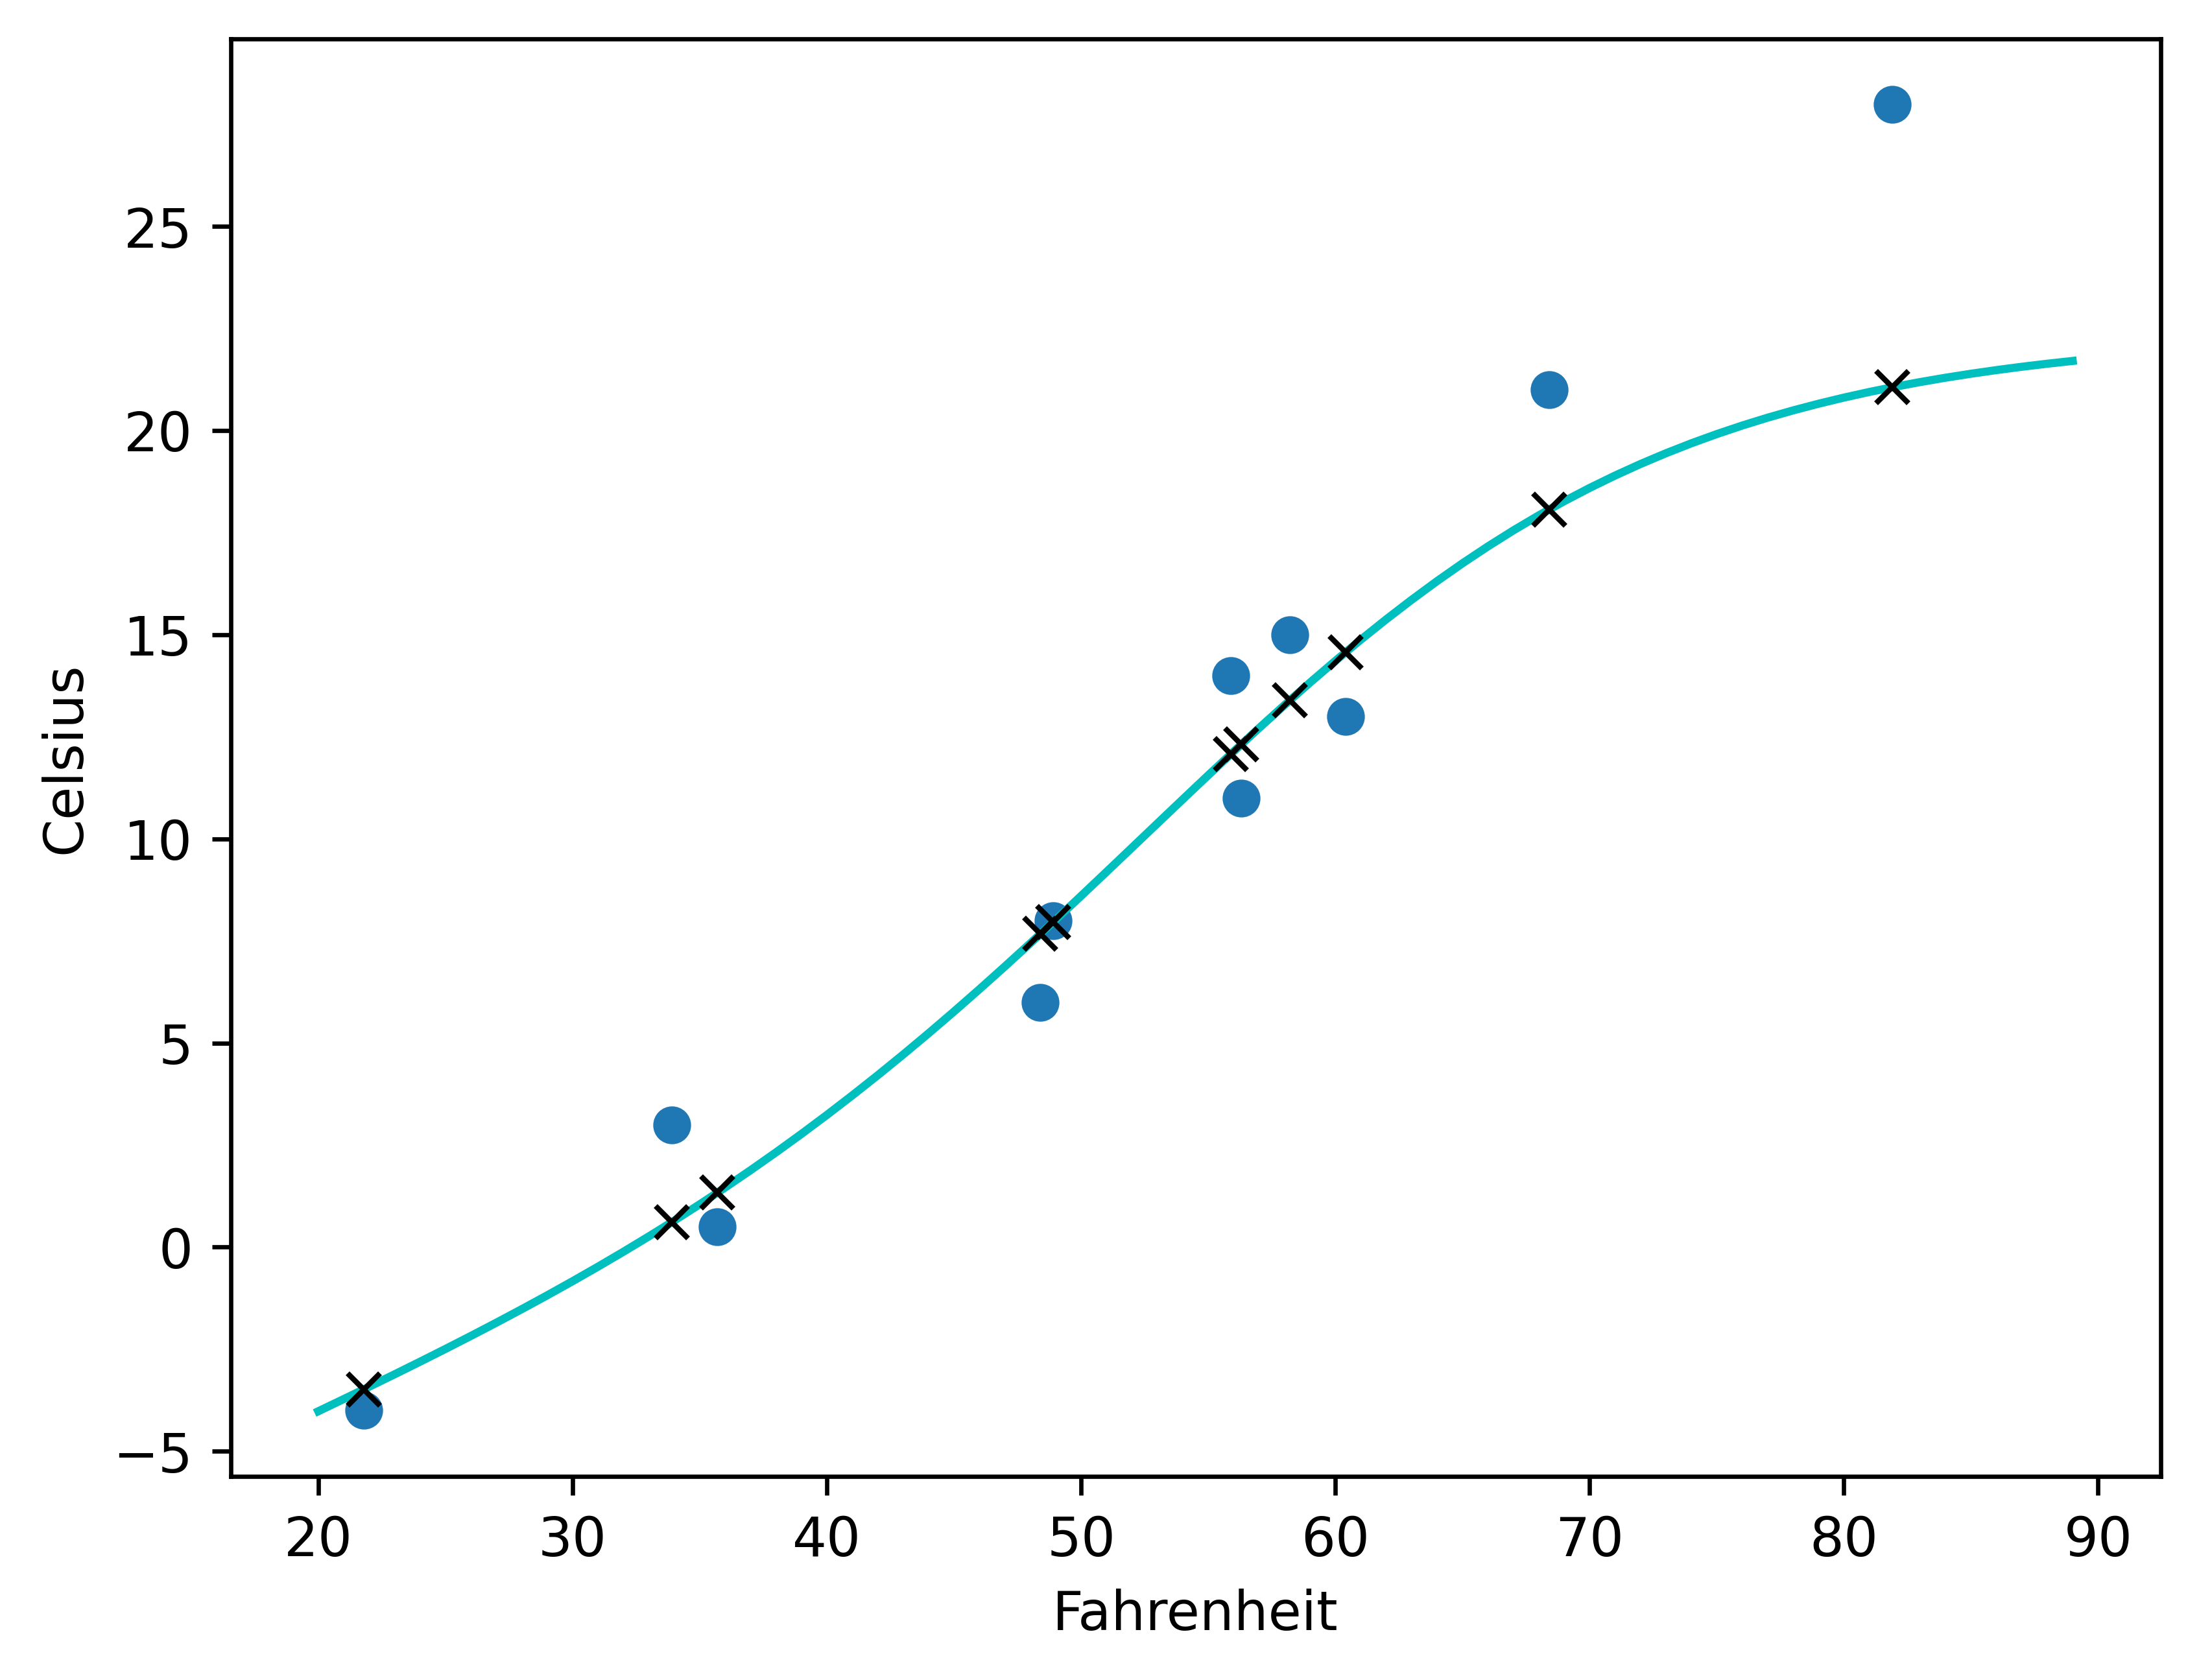

In [70]:
from matplotlib import pyplot as plt

t_range = torch.arange(20.,90.).unsqueeze(1)


fig = plt.figure(dpi=600)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), 'kx')
plt.show()